In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [54]:
df= pd.read_csv('sales_data.csv')
df

,date,region,category,unit_price,quantity,discount_pct,revenue
0,2024-01-01,North,Electronics,348.70,2,0,697.40
1,2024-01-01,East,Books,23.84,2,0,47.67
2,2024-01-01,North,Clothing,15.61,1,0,15.61
3,2024-01-01,South,Electronics,309.40,4,0,1237.59
4,2024-01-01,South,Sports,61.01,4,0,244.05
...,...,...,...,...,...,...,...
6595,2024-12-30,West,Books,32.91,4,5,125.05
6596,2024-12-30,North,Sports,70.54,4,0,282.17
6597,2024-12-30,South,Electronics,387.27,3,0,1161.81
6598,2024-12-30,East,Electronics,383.05,2,20,612.89


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6600 entries, 0 to 6599
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          6600 non-null   str    
 1   region        6600 non-null   str    
 2   category      6600 non-null   str    
 3   unit_price    6600 non-null   float64
 4   quantity      6600 non-null   int64  
 5   discount_pct  6600 non-null   int64  
 6   revenue       6600 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 512.8 KB


In [56]:
df.isnull().sum()

date            0
region          0
category        0
unit_price      0
quantity        0
discount_pct    0
revenue         0
dtype: int64

In [57]:
df.duplicated().sum()

np.int64(0)

In [58]:
df['date']=pd.to_datetime(df['date'])

In [59]:

# Month (as a Period or just the month name/number)
df["month"] = df["date"].dt.month          # 1-12
df["month_name"] = df["date"].dt.month_name()  # "January", "February", ...

# Weekday
df["weekday"] = df["date"].dt.day_name()   # "Monday", "Tuesday", ...
df["weekday_num"] = df["date"].dt.dayofweek  # 0=Monday ... 6=Sunday
df["is_weekend"] = df["weekday_num"] >= 5

# Total revenue = price * quantity
df["total_revenue"] = df["unit_price"] * df["quantity"]

print(df.head())

        date region     category  unit_price  quantity  discount_pct  revenue  \
0 2024-01-01  North  Electronics      348.70         2             0   697.40   
1 2024-01-01   East        Books       23.84         2             0    47.67   
2 2024-01-01  North     Clothing       15.61         1             0    15.61   
3 2024-01-01  South  Electronics      309.40         4             0  1237.59   
4 2024-01-01  South       Sports       61.01         4             0   244.05   

   month month_name weekday  weekday_num  is_weekend  total_revenue  
0      1    January  Monday            0       False         697.40  
1      1    January  Monday            0       False          47.68  
2      1    January  Monday            0       False          15.61  
3      1    January  Monday            0       False        1237.60  
4      1    January  Monday            0       False         244.04  


In [60]:
df.describe()

,date,unit_price,quantity,discount_pct,revenue,month,weekday_num,total_revenue
count,6600,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000
mean,2024-07-01 15:29:40.363636,107.605788,2.484242,3.215152,259.642944,6.520000,3.387273,268.147609
min,2024-01-01 00:00:00,5.640000,1.000000,0.000000,6.680000,1.000000,0.000000,7.530000
25%,2024-03-31 00:00:00,41.117500,2.000000,0.000000,72.415000,3.000000,2.000000,74.830000
50%,2024-07-04 00:00:00,64.415000,2.000000,0.000000,152.260000,7.000000,4.000000,159.700000
75%,2024-09-30 00:00:00,130.987500,3.000000,5.000000,298.752500,9.000000,5.000000,310.117500
max,2024-12-30 00:00:00,566.690000,4.000000,20.000000,2220.860000,12.000000,6.000000,2220.840000
std,NaN,101.736465,1.110528,5.757836,293.203089,3.439018,2.065092,301.558515


In [77]:
category_revenue = df.groupby("category")["revenue"].sum().sort_values(ascending=False).reset_index()


In [78]:
sns.set_theme(style="whitegrid")

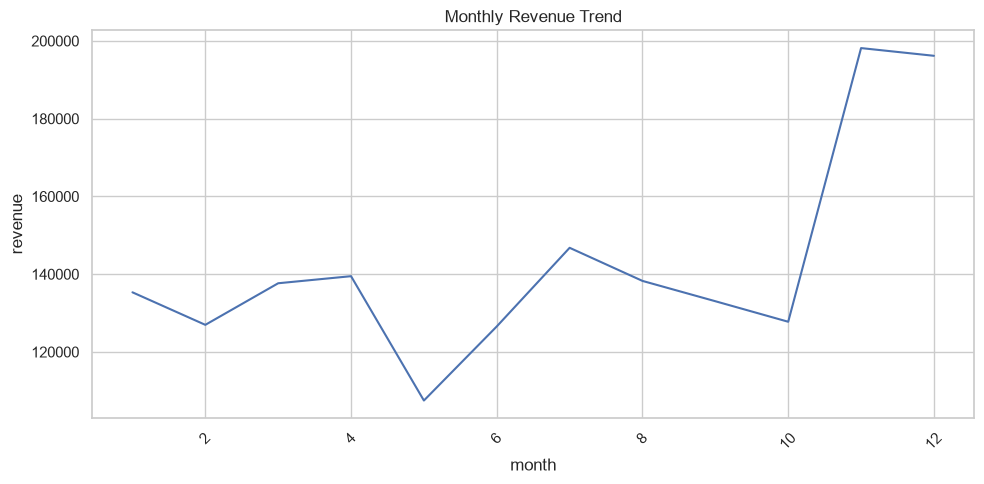

In [79]:
monthly_revenue = df.groupby("month")["revenue"].sum().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_revenue, x="month", y="revenue")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_revenue.png')
plt.show()

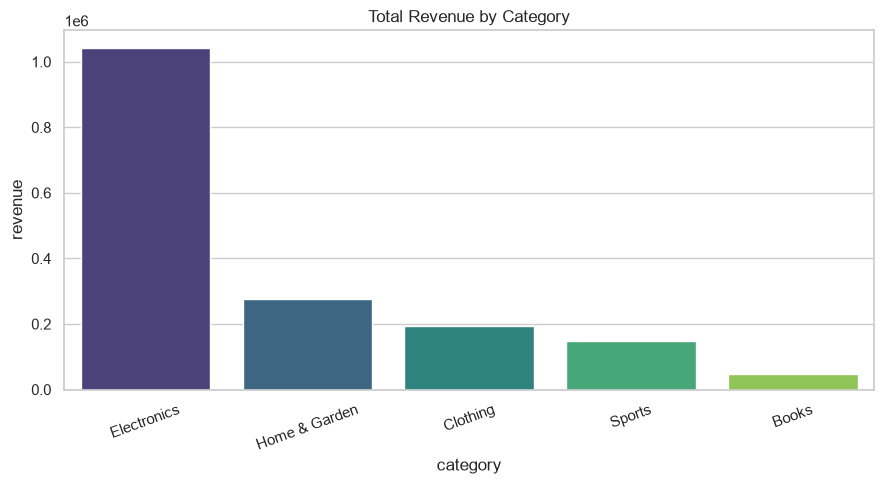

<Figure size 640x480 with 0 Axes>

In [80]:
plt.figure(figsize=(9, 5))
sns.barplot(data=category_revenue, x="category", y="revenue", hue="category", palette="viridis", legend=False)
plt.title("Total Revenue by Category")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
plt.savefig('Total Revenue by Category.png')

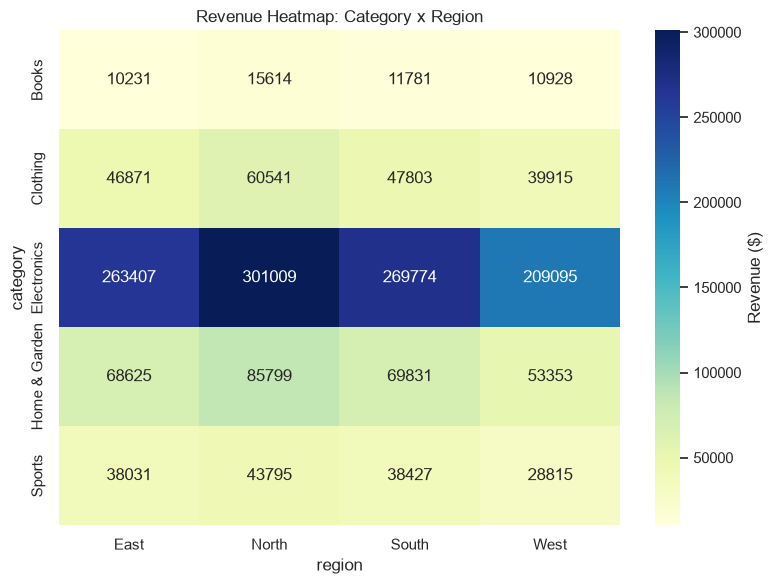

<Figure size 640x480 with 0 Axes>

In [81]:
pivot = df.pivot_table(index="category", columns="region", values="revenue", aggfunc="sum")
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={"label": "Revenue ($)"})
plt.title("Revenue Heatmap: Category x Region")
plt.tight_layout()
plt.show()
plt.savefig('Revenue heaatmap.png')

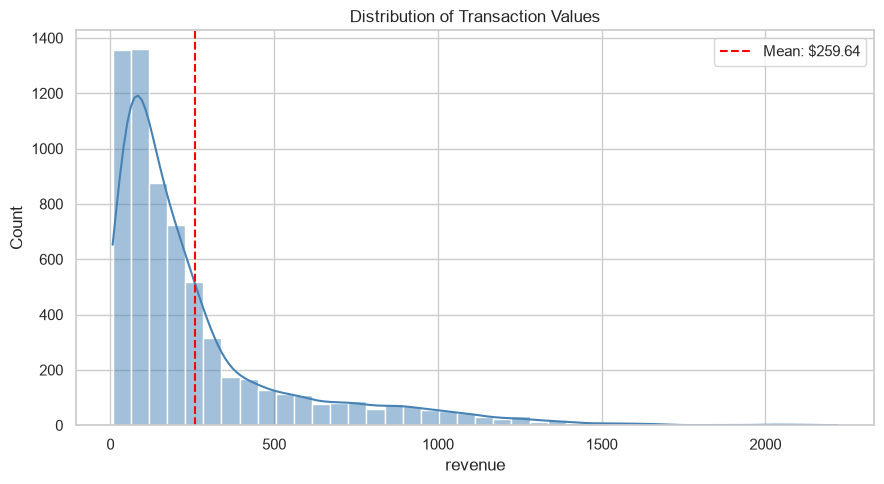

<Figure size 640x480 with 0 Axes>

In [82]:
plt.figure(figsize=(9, 5))
sns.histplot(df["revenue"], bins=40, kde=True, color="steelblue")
plt.axvline(df["revenue"].mean(), color="red", linestyle="--", label=f"Mean: ${df['revenue'].mean():.2f}")
plt.title("Distribution of Transaction Values")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig('Distribution of Transaction Values.png')

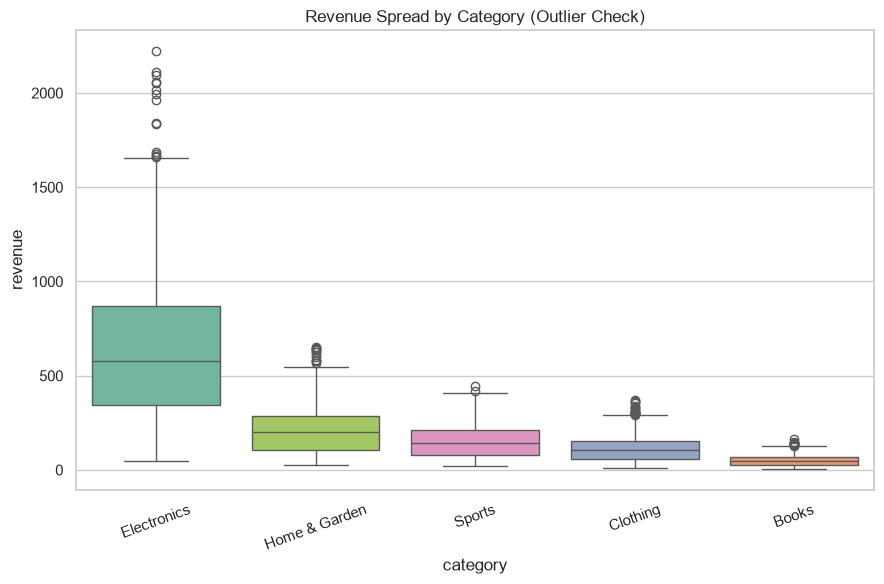

<Figure size 640x480 with 0 Axes>

In [83]:
order = df.groupby("category")["revenue"].median().sort_values(ascending=False).index
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="category", y="revenue", order=order, hue="category", palette="Set2", legend=False)
plt.title("Revenue Spread by Category (Outlier Check)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
plt.savefig('Revenue Spread by Category (Outlier Check).png')